In [19]:
import torch
monitors_folder = 'out/single/fold_0/p1_train_unsupervised/checkpoint_1'
spike_out_trajectory_05 = torch.load(f"{monitors_folder}/monitors/spike_out_trajectory.mon")

In [20]:

import matplotlib.pyplot as plt

def plot_tensor_evolution(data):
    plt.figure(figsize=(10, 6))
    
    # Per ogni elemento (colonna) della lista
    for i in range(data.size(1)):
        plt.plot(data[:, i].numpy(), label=f'Elemento {i}')
        
    plt.xlabel('Step temporale')
    plt.ylabel('Valore')
    plt.title('Andamento dei valori nel tempo per ogni elemento')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

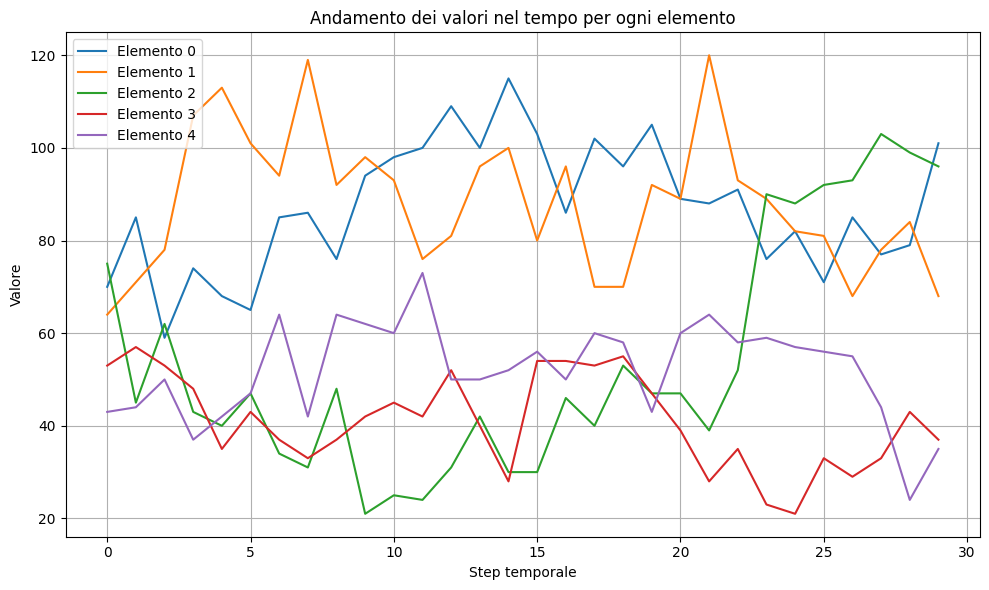

In [21]:
plot_tensor_evolution(spike_out_trajectory_05.squeeze(1))

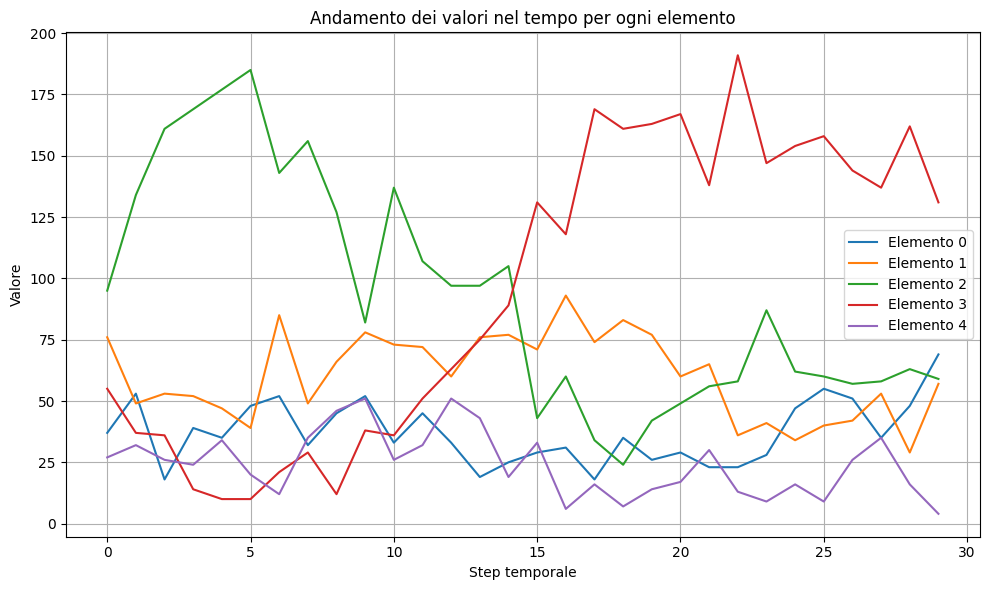

In [15]:
plot_tensor_evolution(spike_out_trajectory_06.squeeze(1))

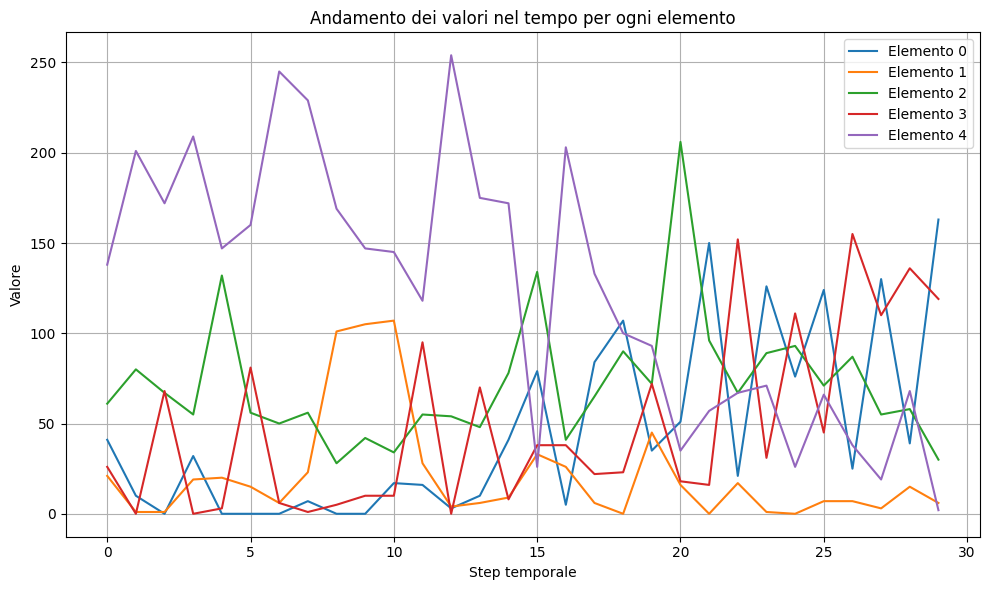

In [16]:
plot_tensor_evolution(spike_out_trajectory_07.squeeze(1))

In [ ]:
import torch


# No reward test
monitors_folder = 'out/split_64/phase_1/checkpoint_1'

# Reward test
#monitors_folder = 'out/workdir_2025-03-25_17-26-57/checkpoint_1'

monitors_folder = 'out/split_164/phase_1/checkpoint_10'


checkpoint_info = torch.load(f"{monitors_folder}/epoch.chk")


pre_input_spike_history = torch.load(f"{monitors_folder}/monitors/pre_input_spike_history.mon")
input_spike_history = torch.load(f"{monitors_folder}/monitors/input_spike_history.mon")
spike_hid_history = torch.load(f"{monitors_folder}/monitors/hidden_spike_history.mon")
spike_out_history = torch.load(f"{monitors_folder}/monitors/spike_out_history.mon")
voltage_history_pre = torch.load(f"{monitors_folder}/monitors/voltage_history_pre.mon")
threshold_history_hid = torch.load(f"{monitors_folder}/monitors/threshold_history_hid.mon")
threshold_history_out = torch.load(f"{monitors_folder}/monitors/threshold_history_out.mon")
out_voltage_history = torch.load(f"{monitors_folder}/monitors/out_voltage_history.mon")
out_synaptic_current_history = torch.load(f"{monitors_folder}/monitors/out_synaptic_current_history.mon")

spike_out_trajectory = torch.load(f"{monitors_folder}/monitors/spike_out_trajectory.mon")
reward_history = torch.load(f"{monitors_folder}/monitors/reward_history.mon")

trajectory_history = torch.load(f"{monitors_folder}/monitors/trajectory_history.mon")

/var/folders/6m/jw_42_bs0p75rv0sycqq52pr0000gn/T/ipykernel_27845/3275363941.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_info = torch.load(f"{monitors_fol

In [15]:
totals = len(trajectory_history)
out_of_target = sum(1 for _, y in trajectory_history if y < 0 or y > 4)
guessed = sum((t == 1).sum().item() for t in reward_history)
accuracy = guessed / (totals-out_of_target)
# accuracy
print(f'accuracy:{accuracy}\ntotals:{totals}\nout of target:{out_of_target}\nguessed:{guessed}')

accuracy:0.0
totals:123
out of target:29
guessed:0


In [16]:
from snntorch import spikeplot as splt
from snntorch import spikegen
import matplotlib.pyplot as plt

#range_lim = [6100, 7500]
range_lim = None

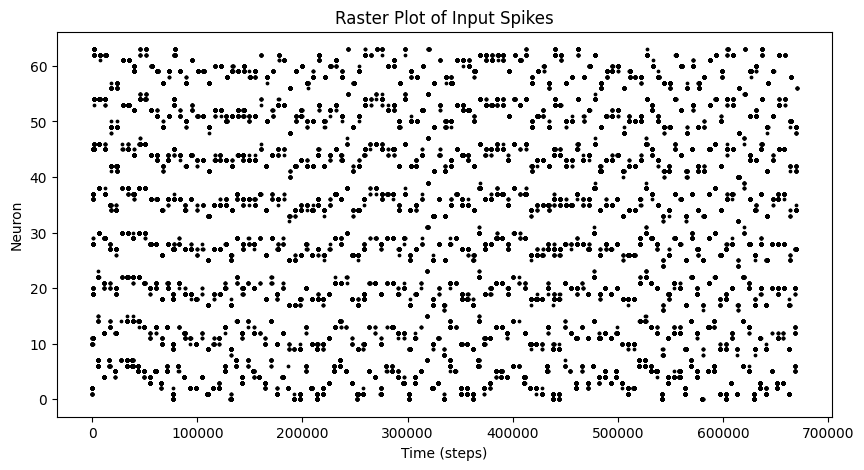

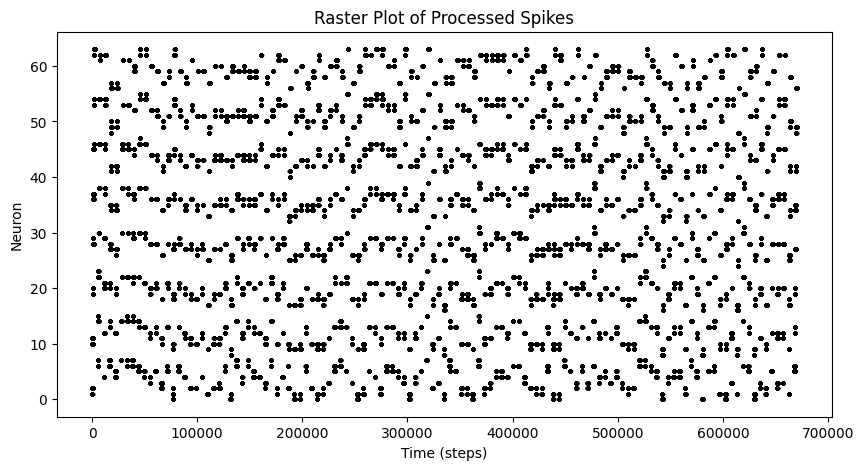

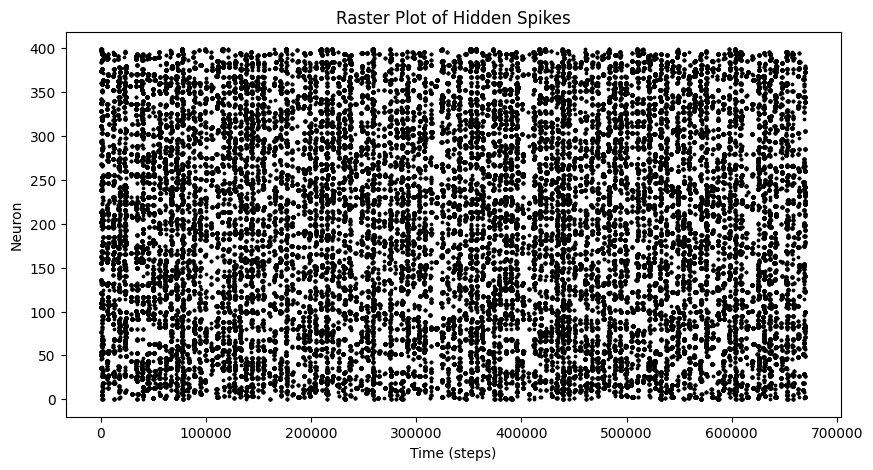

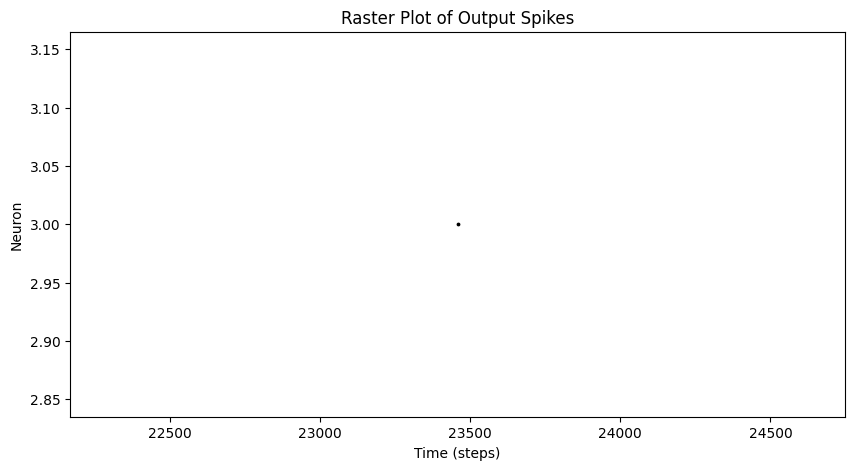

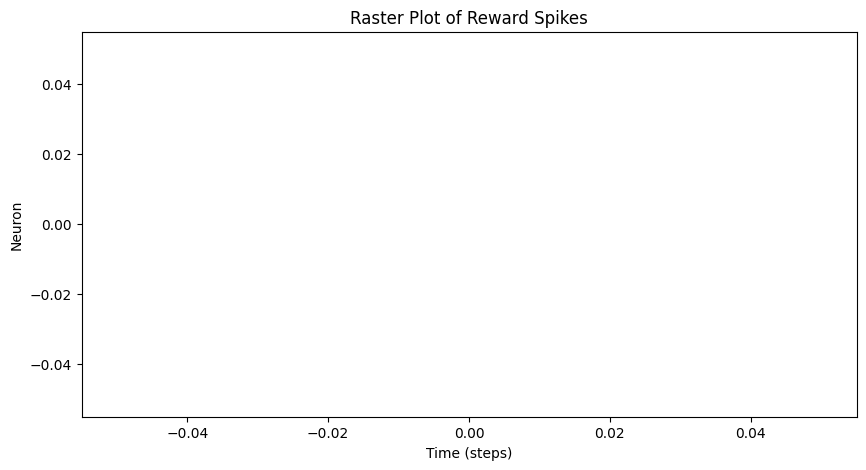

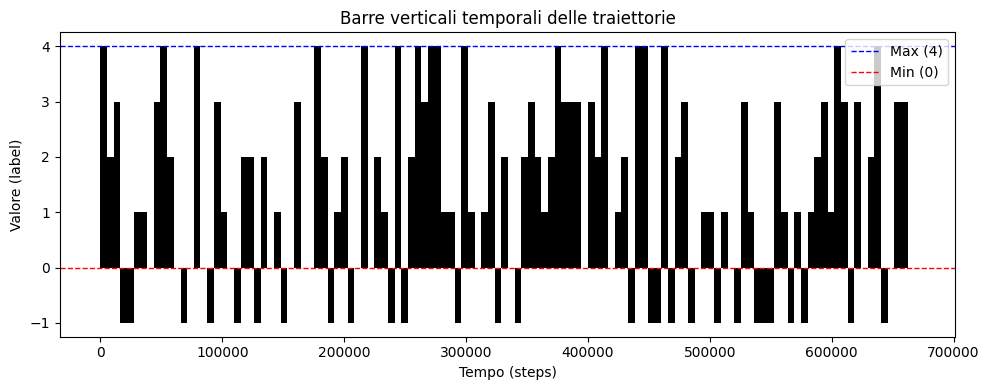

In [17]:
#range_lim = [0, 10000]

# Plot input spikes
fig, ax = plt.subplots(figsize=(10, 5))
splt.raster(pre_input_spike_history.squeeze(1), ax=ax, s=3, c="black", linestyle="-")  # s=3 sets marker size

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Neuron")
ax.set_title("Raster Plot of Input Spikes")

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()

# Plot processed input spikes
fig, ax = plt.subplots(figsize=(10, 5))
splt.raster(input_spike_history.squeeze(1), ax=ax, s=3, c="black", linestyle="-")  # s=3 sets marker size

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Neuron")
ax.set_title("Raster Plot of Processed Spikes")

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()


# Plot hidden spikes
fig, ax = plt.subplots(figsize=(10, 5))
splt.raster(spike_hid_history.squeeze(1), ax=ax, s=3, c="black", linestyle="-")  # s=3 sets marker size

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Neuron")
ax.set_title("Raster Plot of Hidden Spikes")

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()


# Plot output spikes
fig, ax = plt.subplots(figsize=(10, 5))
splt.raster(spike_out_history.squeeze(1), ax=ax, s=3, c="black", linestyle="-")  # s=3 sets marker size

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Neuron")
ax.set_title("Raster Plot of Output Spikes")

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()


# Plot reward spikes
fig, ax = plt.subplots(figsize=(10, 5))
splt.raster(reward_history.squeeze(1), ax=ax, s=3, c="black", linestyle="-")  # s=3 sets marker size

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Neuron")
ax.set_title("Raster Plot of Reward Spikes")

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()



# Plot trajectory target position
x_vals = [x[0] for x in trajectory_history]
y_vals = [x[1] for x in trajectory_history]

# Calcola le larghezze come la differenza tra timestamp successivi
widths = [x_vals[i+1] - x_vals[i] for i in range(len(x_vals)-1)]

# Elimina l'ultimo valore (non ha una fine successiva)
x_vals = x_vals[:-1]
y_vals = y_vals[:-1]

# Plot verticale a barre larghezza variabile
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_vals, y_vals, width=widths, align='edge', color='black')

# Aggiungi linee orizzontali a y = 0 e y = 4
ax.axhline(4, color='blue', linestyle='--', linewidth=1, label='Max (4)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Min (0)')


# Legenda e info grafiche
ax.set_xlabel("Tempo (steps)")
ax.set_ylabel("Valore (label)")
ax.set_title("Barre verticali temporali delle traiettorie")
ax.legend()
plt.tight_layout()
plt.show()

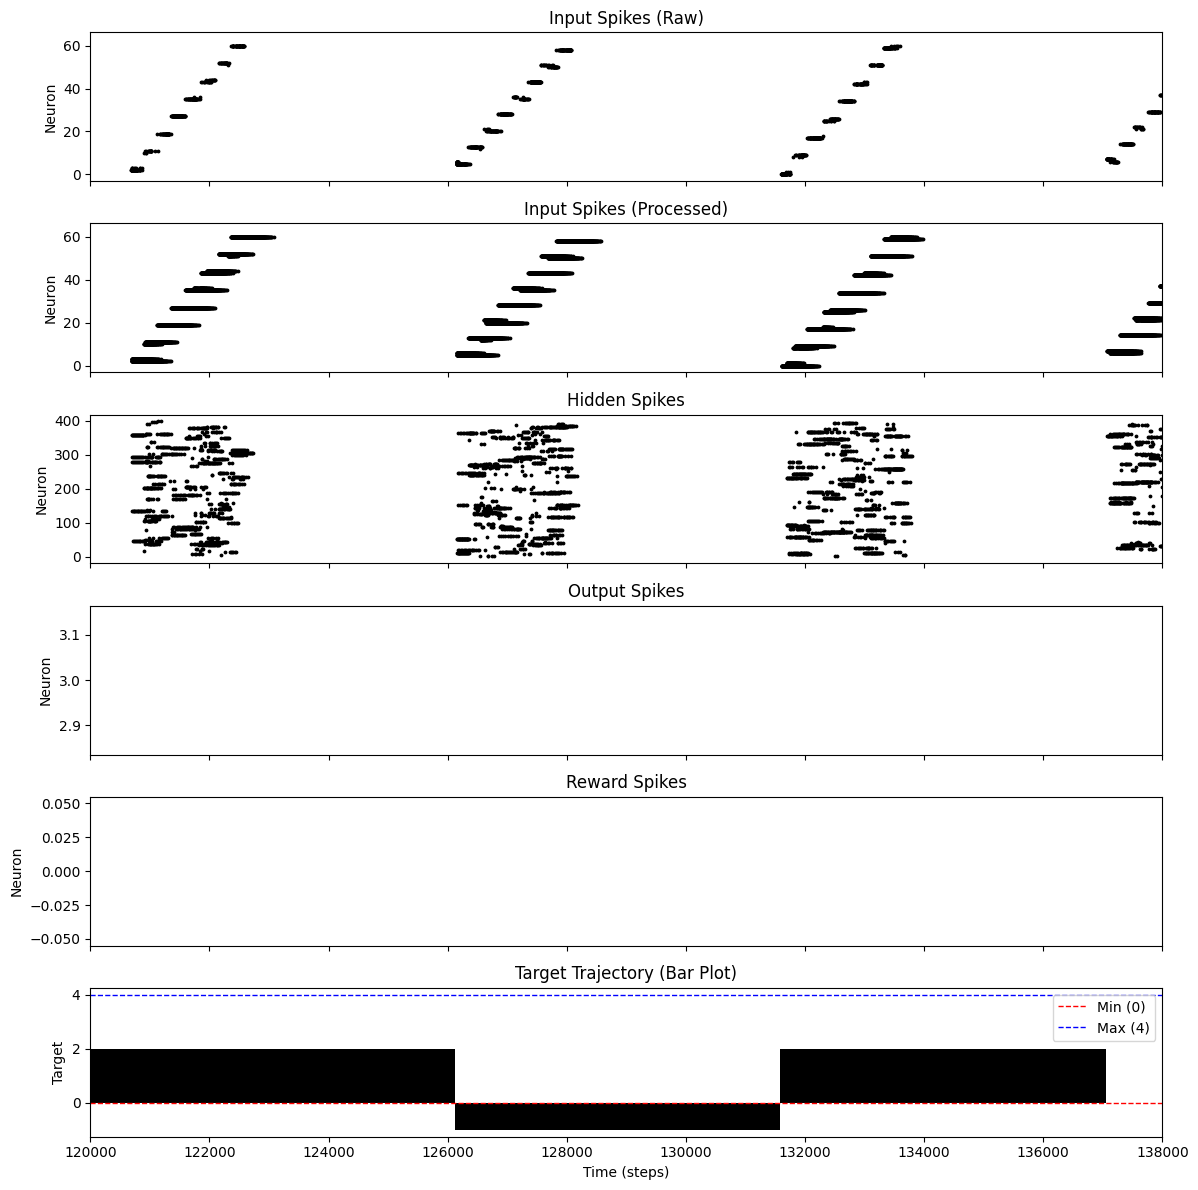

In [18]:
import matplotlib.pyplot as plt
from snntorch import spikeplot as splt

range_lim=[120000, 138000]
#range_lim=None

def plot_all_raster_traces(
    pre_input_spike_history,
    input_spike_history,
    spike_hid_history,
    spike_out_history,
    reward_history,
    trajectory_history,
    range_lim=None,
    figsize=(12, 12),
    marker_size=3
):
    # Crea figura con 6 subplot allineati verticalmente, che condividono l'asse x
    fig, axs = plt.subplots(6, 1, figsize=figsize, sharex=True)

    # Lista dei dati e dei titoli corrispondenti
    spike_data = [
        (pre_input_spike_history, "Input Spikes (Raw)"),
        (input_spike_history, "Input Spikes (Processed)"),
        (spike_hid_history, "Hidden Spikes"),
        (spike_out_history, "Output Spikes"),
        (reward_history, "Reward Spikes")
    ]

    for i, (tensor, title) in enumerate(spike_data):
        splt.raster(tensor.squeeze(1), ax=axs[i], s=marker_size, c="black", linestyle="-")
        axs[i].set_ylabel("Neuron")
        axs[i].set_title(title)
        if range_lim is not None:
            axs[i].set_xlim(range_lim)

    # --- Nuovo subplot per trajectory_history ---
    x_vals = [x[0] for x in trajectory_history]
    y_vals = [x[1] for x in trajectory_history]

    # Calcola larghezze variabili
    widths = [x_vals[i+1] - x_vals[i] for i in range(len(x_vals) - 1)]
    x_vals = x_vals[:-1]
    y_vals = y_vals[:-1]

    axs[5].bar(x_vals, y_vals, width=widths, align='edge', color='black')
    axs[5].axhline(0, color='red', linestyle='--', linewidth=1, label='Min (0)')
    axs[5].axhline(4, color='blue', linestyle='--', linewidth=1, label='Max (4)')
    axs[5].set_ylabel("Target")
    axs[5].set_title("Target Trajectory (Bar Plot)")
    axs[5].legend()

    if range_lim is not None:
        axs[5].set_xlim(range_lim)

    axs[-1].set_xlabel("Time (steps)")

    plt.tight_layout()
    plt.show()
    
plot_all_raster_traces(
    pre_input_spike_history,
    input_spike_history,
    spike_hid_history,
    spike_out_history,
    reward_history,
    trajectory_history,
    range_lim=range_lim  # oppure None [5500, 12000] 
)

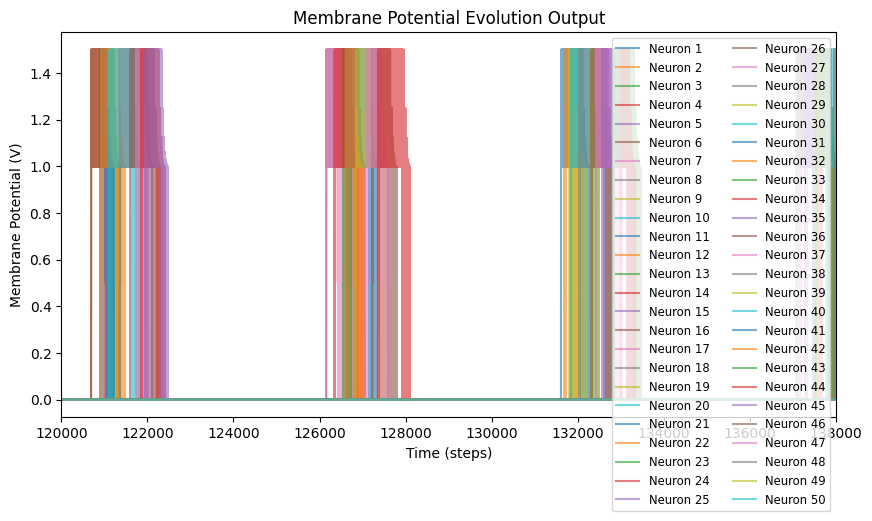

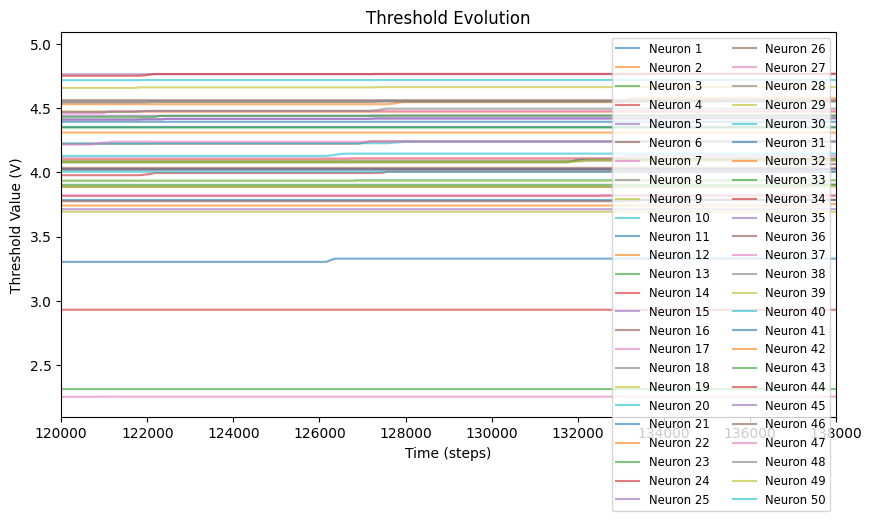

In [19]:


# Time axis
time = torch.arange(voltage_history_pre.shape[0])  


# Plot membrane potentials for output neurons
fig, ax = plt.subplots(figsize=(10, 5))

voltage_history_pre = voltage_history_pre.squeeze(1)

for neuron_id in range(50):  
    ax.plot(time, voltage_history_pre[:, neuron_id], label=f"Neuron {neuron_id+1}", alpha=0.6)

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Membrane Potential (V)")
ax.set_title("Membrane Potential Evolution Output")
ax.legend(loc="upper right", fontsize="small", ncol=2)  

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()




# Plot threshold evolution
fig, ax = plt.subplots(figsize=(10, 5))

threshold_history_hid = threshold_history_hid.squeeze(1)

for neuron_id in range(50):  
    ax.plot(time, threshold_history_hid[:, neuron_id], label=f"Neuron {neuron_id+1}", alpha=0.6)

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Threshold Value (V)")
ax.set_title("Threshold Evolution")
ax.legend(loc="upper right", fontsize="small", ncol=2)  

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()


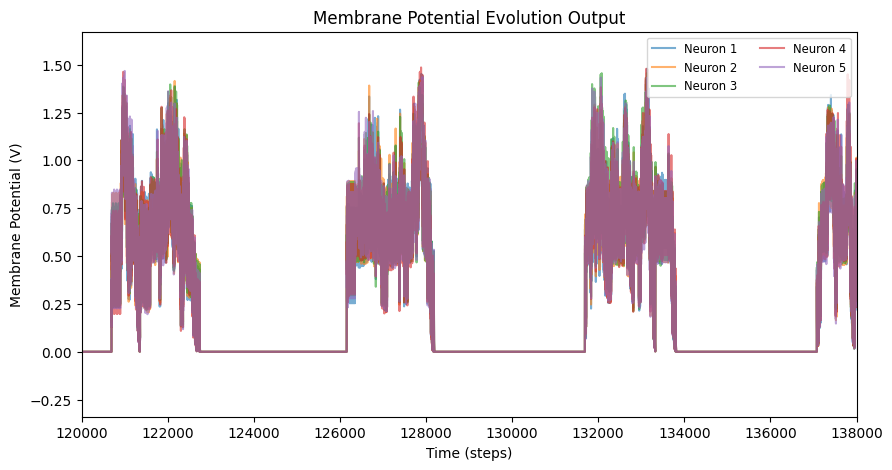

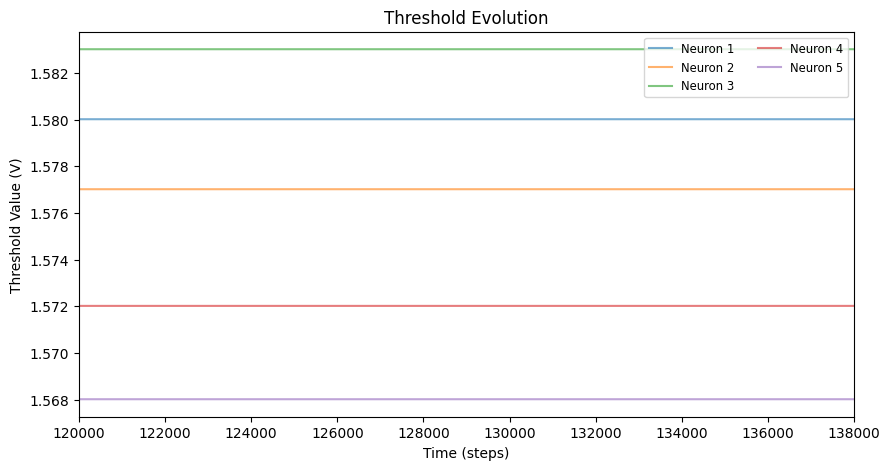

In [20]:
# Plot membrane potentials for output neurons
fig, ax = plt.subplots(figsize=(10, 5))

out_voltage_history = out_voltage_history.squeeze(1)

for neuron_id in range(out_voltage_history.shape[1]):  
    ax.plot(time, out_voltage_history[:, neuron_id], label=f"Neuron {neuron_id+1}", alpha=0.6)

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Membrane Potential (V)")
ax.set_title("Membrane Potential Evolution Output")
ax.legend(loc="upper right", fontsize="small", ncol=2)  

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()


threshold_history_out = threshold_history_out.squeeze(1)

# Plot threshold evolution
fig, ax = plt.subplots(figsize=(10, 5))

for neuron_id in range(threshold_history_out.shape[1]):  
    ax.plot(time, threshold_history_out[:, neuron_id], label=f"Neuron {neuron_id+1}", alpha=0.6)

ax.set_xlabel("Time (steps)")
ax.set_ylabel("Threshold Value (V)")
ax.set_title("Threshold Evolution")
ax.legend(loc="upper right", fontsize="small", ncol=2)  

if range_lim is not None:
    ax.set_xlim(range_lim)
plt.show()

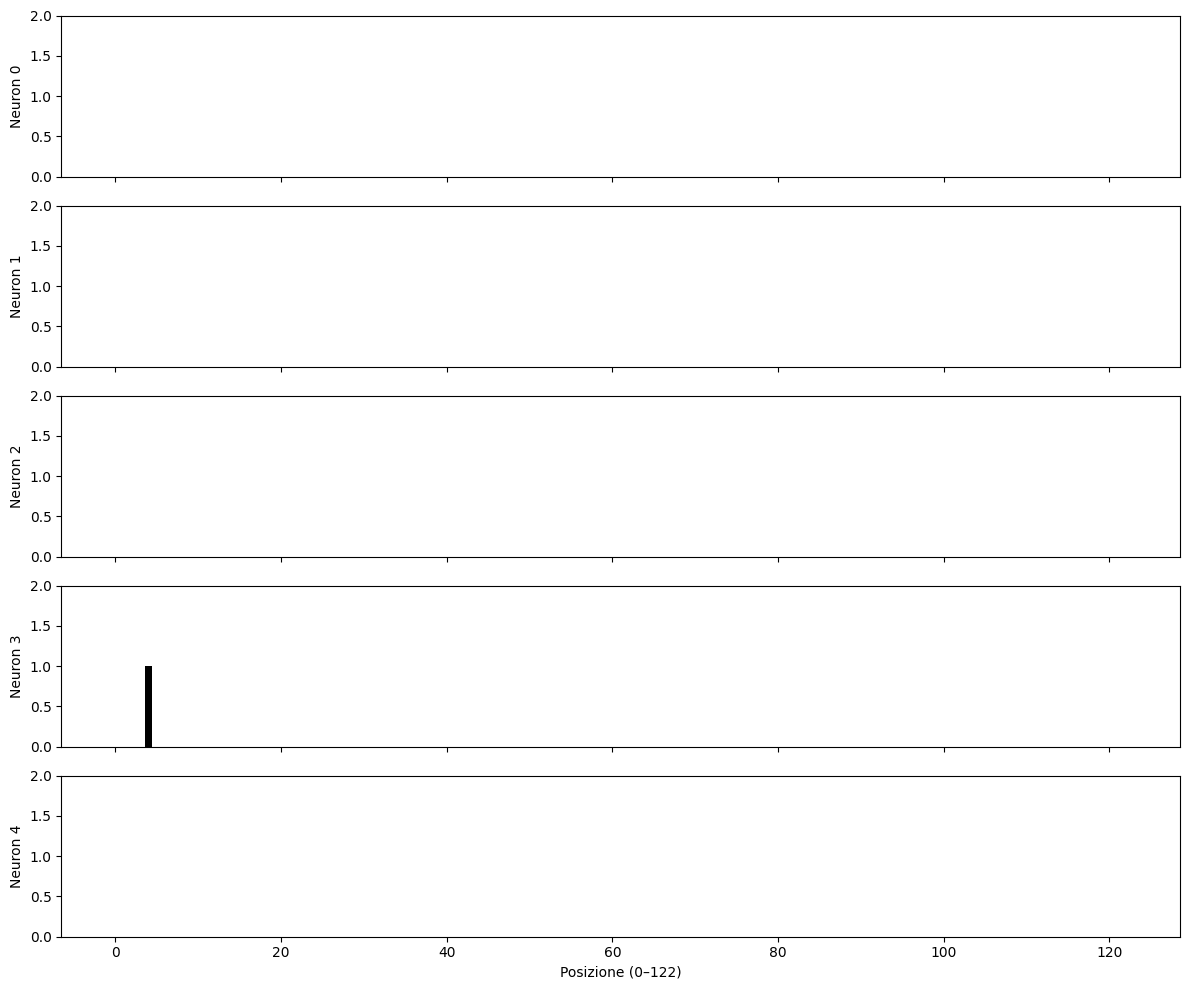

In [21]:
def plot_spike_list_subplots(spike_tensor, figsize=(12, 10), savepath=None):
    """
    Plotta i dati di spike in 5 subplot.
    
    Parametri:
    - spike_tensor: torch.Tensor di shape (64, batch_size, 5)
    - figsize: dimensioni della figura matplotlib
    - savepath: se specificato, salva la figura nel file indicato (es. "spikes.png")
    """
    if spike_tensor.dim() != 3 or spike_tensor.shape[0] != 64 or spike_tensor.shape[2] != 5:
        raise ValueError("Il tensore deve avere shape (64, batch_size, 5)")

    # Somma gli spike su batch se > 1 → shape: (64, 5)
    spike_counts = spike_tensor.sum(dim=1)

    positions = list(range(64))  # Asse x

    fig, axs = plt.subplots(5, 1, figsize=figsize, sharex=True)

    for neuron_idx in range(5):
        axs[neuron_idx].bar(positions, spike_counts[:, neuron_idx].tolist(), color="black")
        axs[neuron_idx].set_ylabel(f"Neuron {neuron_idx}")
        axs[neuron_idx].set_ylim(0, spike_counts.max().item() + 1)

    axs[-1].set_xlabel("Posizione (0-63)")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
        
        
        
def plot_spike_subplots(spike_tensor, figsize=(12, 10), savepath=None):
    """
    Plotta i dati di spike in 5 subplot.
    
    Parametri:
    - spike_tensor: torch.Tensor di shape (N, 1, 5)
    - figsize: dimensioni della figura matplotlib
    - savepath: se specificato, salva la figura nel file indicato (es. "spikes.png")
    """
    if spike_tensor.dim() != 3 or spike_tensor.shape[2] != 5:
        raise ValueError("Il tensore deve avere shape (N, 1, 5)")

    # Rimuove la dimensione del batch (se è 1) → shape: (N, 5)
    spike_tensor = spike_tensor.squeeze(1)

    num_positions = spike_tensor.shape[0]
    positions = list(range(num_positions))  # Asse x: da 0 a N-1

    fig, axs = plt.subplots(5, 1, figsize=figsize, sharex=True)

    for neuron_idx in range(5):
        axs[neuron_idx].bar(positions, spike_tensor[:, neuron_idx].tolist(), color="black")
        axs[neuron_idx].set_ylabel(f"Neuron {neuron_idx}")
        axs[neuron_idx].set_ylim(0, spike_tensor.max().item() + 1)

    axs[-1].set_xlabel(f"Posizione (0–{num_positions - 1})")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
      
if isinstance(spike_out_trajectory, torch.Tensor):
    plot_spike_subplots(spike_out_trajectory)
else:
    plot_spike_list_subplots(spike_out_trajectory)